# Лабораторная №3

Подробные пояснения вынесены в [README.md](/Users/nikitagerasimov/Desktop/Study/6%20semestr/CV/CV-GerasimovNS-M3303/lab3/README.md).

В этой работе на `MNIST` сравниваются:

- `MLP` c `ReLU` и регуляризацией;
- `MLP` без регуляризации;
- `MLP` с сигмоидой;
- простая `CNN`.


In [72]:
from dataclasses import dataclass
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cpu')

## 1. Загрузка MNIST


train: (60000, 28, 28) (60000,)
test:  (10000, 28, 28) (10000,)


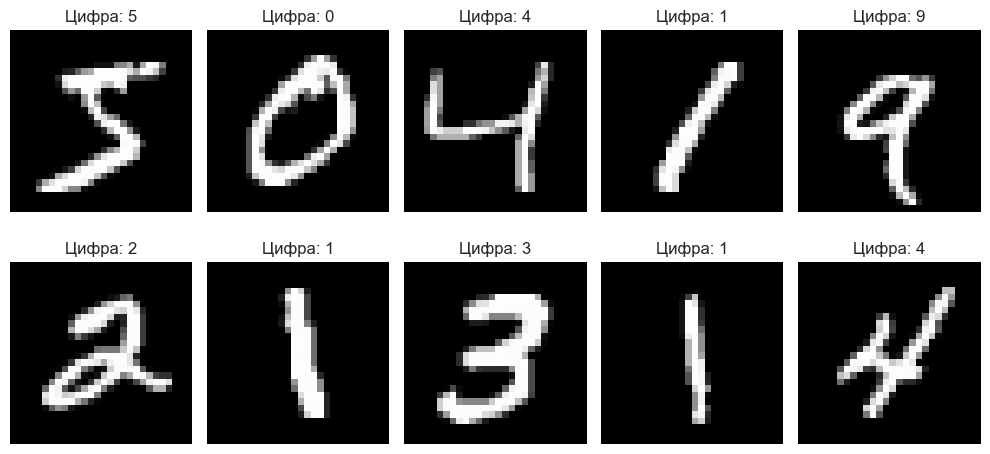

In [73]:
data_path = Path('data/mnist.npz')

with np.load(data_path) as data:
    x_train_full_np = data['x_train'].astype(np.float32) / 255.0
    y_train_full_np = data['y_train'].astype(np.int64)
    x_test_np = data['x_test'].astype(np.float32) / 255.0
    y_test_np = data['y_test'].astype(np.int64)

print('train:', x_train_full_np.shape, y_train_full_np.shape)
print('test: ', x_test_np.shape, y_test_np.shape)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for idx, ax in enumerate(axes.ravel()):
    ax.imshow(x_train_full_np[idx], cmap='gray')
    ax.set_title(f'Цифра: {y_train_full_np[idx]}')
    ax.axis('off')
plt.tight_layout()
plt.show()


## 2. Подготовка выборок


In [74]:
x_train_tensor = torch.tensor(x_train_full_np, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train_full_np, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_np, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.long)

full_train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [50000, 10000],
    generator=torch.Generator().manual_seed(SEED),
)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

print('train size:', len(train_dataset))
print('val size:  ', len(val_dataset))
print('test size: ', len(test_dataset))


train size: 50000
val size:   10000
test size:  10000


## 3. Базовая MLP: ReLU + регуляризация


In [75]:
@dataclass
class TrainConfig:
    epochs: int = 6
    batch_size: int = 256
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    dropout_rate: float = 0.2


config = TrainConfig()


In [76]:
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)


In [77]:
class MLPClassifier(nn.Module):
    def __init__(self, activation='relu', dropout_rate=0.2):
        super().__init__()
        activation_layer = nn.ReLU if activation == 'relu' else nn.Sigmoid

        layers = [nn.Flatten(), nn.Linear(28 * 28, 256), activation_layer()]
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))

        layers.extend([nn.Linear(256, 128), activation_layer()])
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))

        layers.append(nn.Linear(128, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


In [78]:
def evaluate_model(model, loader, criterion):
    model.eval()
    losses = []
    predictions = []
    targets = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            losses.append(loss.item())
            predictions.extend(torch.argmax(logits, dim=1).cpu().numpy())
            targets.extend(batch_y.cpu().numpy())

    accuracy = accuracy_score(targets, predictions)
    macro_f1 = f1_score(targets, predictions, average='macro')
    return float(np.mean(losses)), accuracy, macro_f1


def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_accuracy': [],
        'val_accuracy': [],
        'train_f1': [],
        'val_f1': [],
    }

    for epoch in range(epochs):
        model.train()
        train_losses = []
        train_predictions = []
        train_targets = []

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            train_predictions.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())
            train_targets.extend(batch_y.cpu().numpy())

        train_accuracy = accuracy_score(train_targets, train_predictions)
        train_f1 = f1_score(train_targets, train_predictions, average='macro')
        val_loss, val_accuracy, val_f1 = evaluate_model(model, val_loader, criterion)

        history['train_loss'].append(float(np.mean(train_losses)))
        history['val_loss'].append(val_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_accuracy'].append(val_accuracy)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        print(
            f"Эпоха {epoch + 1:02d}/{epochs} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_accuracy:.4f} | "
            f"val_f1={val_f1:.4f}"
        )

    return history


In [79]:
criterion = nn.CrossEntropyLoss()

baseline_model = MLPClassifier(activation='relu', dropout_rate=config.dropout_rate).to(device)
baseline_optimizer = torch.optim.AdamW(
    baseline_model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
)

baseline_history = train_model(
    baseline_model,
    train_loader,
    val_loader,
    baseline_optimizer,
    criterion,
    config.epochs,
)

baseline_test_loss, baseline_test_acc, baseline_test_f1 = evaluate_model(baseline_model, test_loader, criterion)
print(f'\nТестовая потеря:   {baseline_test_loss:.4f}')
print(f'Тестовая accuracy: {baseline_test_acc:.4f}')
print(f'Тестовая macro F1: {baseline_test_f1:.4f}')


Эпоха 01/6 | val_loss=0.2403 | val_acc=0.9297 | val_f1=0.9289
Эпоха 02/6 | val_loss=0.1667 | val_acc=0.9487 | val_f1=0.9482
Эпоха 03/6 | val_loss=0.1354 | val_acc=0.9593 | val_f1=0.9589
Эпоха 04/6 | val_loss=0.1152 | val_acc=0.9656 | val_f1=0.9653
Эпоха 05/6 | val_loss=0.1003 | val_acc=0.9692 | val_f1=0.9689
Эпоха 06/6 | val_loss=0.0927 | val_acc=0.9717 | val_f1=0.9714

Тестовая потеря:   0.0787
Тестовая accuracy: 0.9766
Тестовая macro F1: 0.9764


In [80]:
def plot_history(history, title_prefix=''):
    epochs = np.arange(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(epochs, history['train_loss'], label='Train loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], label='Validation loss', linewidth=2)
    axes[0].set_title(f'{title_prefix}Функция потерь по эпохам')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(epochs, history['train_accuracy'], label='Train accuracy', linewidth=2)
    axes[1].plot(epochs, history['val_accuracy'], label='Validation accuracy', linewidth=2)
    axes[1].plot(epochs, history['train_f1'], label='Train macro F1', linewidth=2, linestyle='--')
    axes[1].plot(epochs, history['val_f1'], label='Validation macro F1', linewidth=2, linestyle='--')
    axes[1].set_title(f'{title_prefix}Метрики качества по эпохам')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('Значение метрики')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


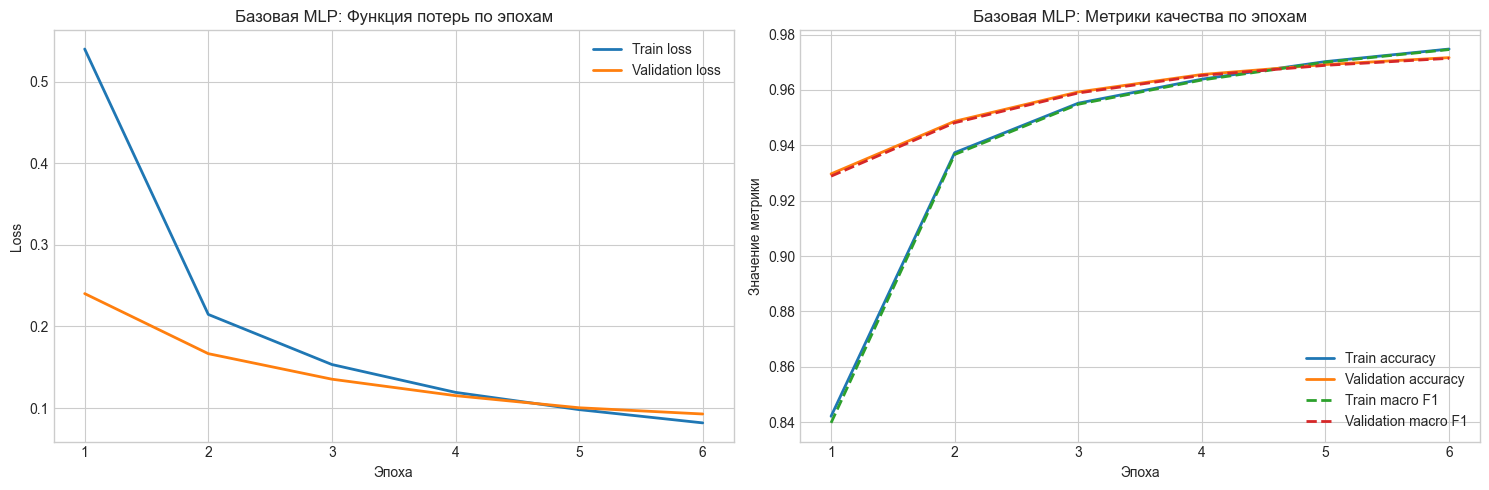

In [81]:
plot_history(baseline_history, title_prefix='Базовая MLP: ')


## 4. MLP без регуляризации


In [82]:
no_reg_model = MLPClassifier(activation='relu', dropout_rate=0.0).to(device)
no_reg_optimizer = torch.optim.AdamW(
    no_reg_model.parameters(),
    lr=config.learning_rate,
    weight_decay=0.0,
)

no_reg_history = train_model(
    no_reg_model,
    train_loader,
    val_loader,
    no_reg_optimizer,
    criterion,
    config.epochs,
)

no_reg_test_loss, no_reg_test_acc, no_reg_test_f1 = evaluate_model(no_reg_model, test_loader, criterion)
print(f'\nТестовая потеря:   {no_reg_test_loss:.4f}')
print(f'Тестовая accuracy: {no_reg_test_acc:.4f}')
print(f'Тестовая macro F1: {no_reg_test_f1:.4f}')


Эпоха 01/6 | val_loss=0.2517 | val_acc=0.9283 | val_f1=0.9275
Эпоха 02/6 | val_loss=0.1718 | val_acc=0.9489 | val_f1=0.9483
Эпоха 03/6 | val_loss=0.1363 | val_acc=0.9592 | val_f1=0.9587
Эпоха 04/6 | val_loss=0.1178 | val_acc=0.9642 | val_f1=0.9637
Эпоха 05/6 | val_loss=0.1016 | val_acc=0.9681 | val_f1=0.9678
Эпоха 06/6 | val_loss=0.1005 | val_acc=0.9678 | val_f1=0.9674

Тестовая потеря:   0.0883
Тестовая accuracy: 0.9740
Тестовая macro F1: 0.9738


In [83]:
def plot_comparison(histories, metric_key, title, ylabel):
    epochs = np.arange(1, len(next(iter(histories.values()))[metric_key]) + 1)
    plt.figure(figsize=(10, 5))
    for label, history in histories.items():
        plt.plot(epochs, history[metric_key], label=label, linewidth=2)
    plt.title(title)
    plt.xlabel('Эпоха')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


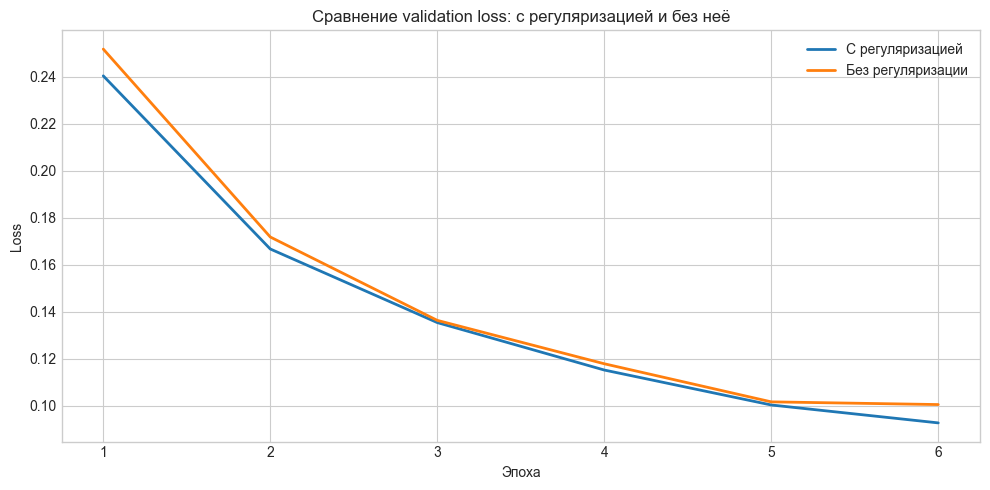

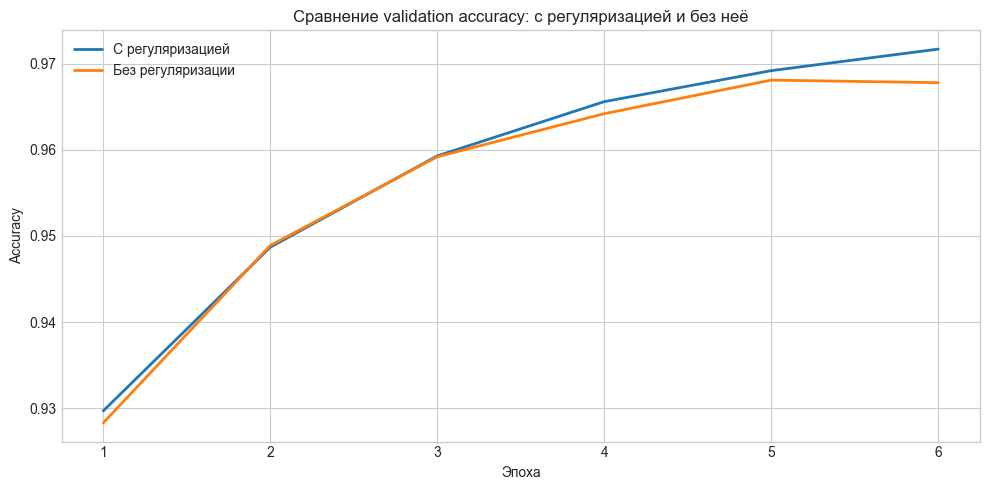

In [84]:
plot_comparison(
    {'С регуляризацией': baseline_history, 'Без регуляризации': no_reg_history},
    'val_loss',
    'Сравнение validation loss: с регуляризацией и без неё',
    'Loss',
)

plot_comparison(
    {'С регуляризацией': baseline_history, 'Без регуляризации': no_reg_history},
    'val_accuracy',
    'Сравнение validation accuracy: с регуляризацией и без неё',
    'Accuracy',
)

 на MNIST удаление регуляризации ухудшило качество слабо, потому что датасет сравнительно простой, а сеть умеренного размера. Но базовая модель с регуляризацией всё равно показывает чуть более устойчивый результат.

## 5. MLP с сигмоидой


In [85]:
sigmoid_model = MLPClassifier(activation='sigmoid', dropout_rate=config.dropout_rate).to(device)
sigmoid_optimizer = torch.optim.AdamW(
    sigmoid_model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
)

sigmoid_history = train_model(
    sigmoid_model,
    train_loader,
    val_loader,
    sigmoid_optimizer,
    criterion,
    config.epochs,
)

sigmoid_test_loss, sigmoid_test_acc, sigmoid_test_f1 = evaluate_model(sigmoid_model, test_loader, criterion)
print(f'\nТестовая потеря:   {sigmoid_test_loss:.4f}')
print(f'Тестовая accuracy: {sigmoid_test_acc:.4f}')
print(f'Тестовая macro F1: {sigmoid_test_f1:.4f}')


Эпоха 01/6 | val_loss=0.4765 | val_acc=0.8771 | val_f1=0.8751
Эпоха 02/6 | val_loss=0.3038 | val_acc=0.9110 | val_f1=0.9095
Эпоха 03/6 | val_loss=0.2518 | val_acc=0.9253 | val_f1=0.9242
Эпоха 04/6 | val_loss=0.2216 | val_acc=0.9334 | val_f1=0.9326
Эпоха 05/6 | val_loss=0.1922 | val_acc=0.9431 | val_f1=0.9424
Эпоха 06/6 | val_loss=0.1746 | val_acc=0.9477 | val_f1=0.9471

Тестовая потеря:   0.1605
Тестовая accuracy: 0.9527
Тестовая macro F1: 0.9523


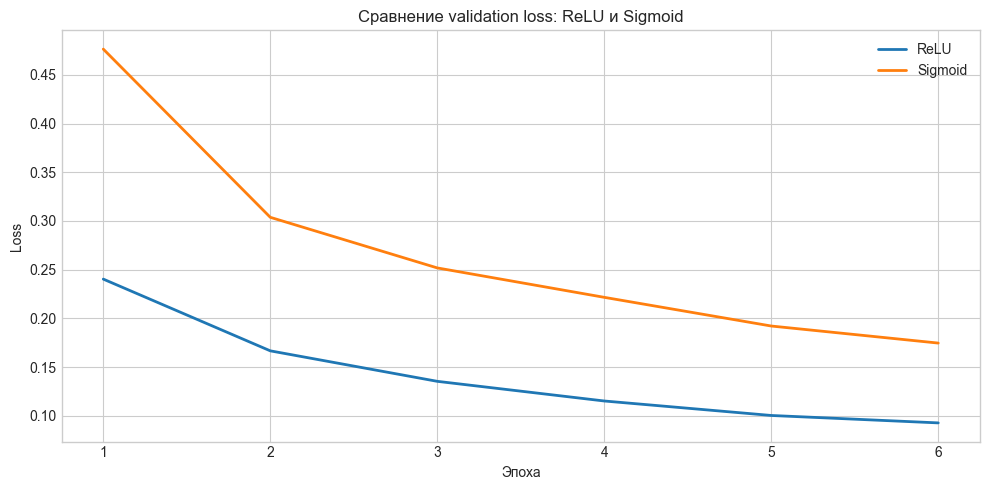

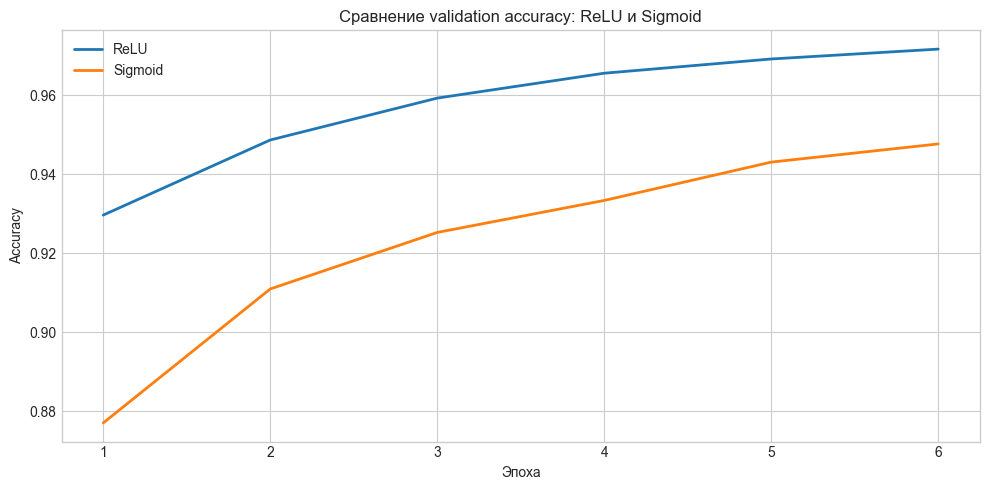

In [86]:
plot_comparison(
    {'ReLU': baseline_history, 'Sigmoid': sigmoid_history},
    'val_loss',
    'Сравнение validation loss: ReLU и Sigmoid',
    'Loss',
)

plot_comparison(
    {'ReLU': baseline_history, 'Sigmoid': sigmoid_history},
    'val_accuracy',
    'Сравнение validation accuracy: ReLU и Sigmoid',
    'Accuracy',
)



модель с сигмоидой обучается медленнее и показывает более слабые метрики. Это происходит из-за насыщения сигмоиды и более выраженного затухание градиента.

## 6. Итоговое сравнение MLP


In [87]:
mlp_results = {
    'ReLU + regularization': (baseline_test_loss, baseline_test_acc, baseline_test_f1),
    'ReLU without regularization': (no_reg_test_loss, no_reg_test_acc, no_reg_test_f1),
    'Sigmoid + regularization': (sigmoid_test_loss, sigmoid_test_acc, sigmoid_test_f1),
}

for model_name, (loss_value, accuracy_value, f1_value) in mlp_results.items():
    print(model_name)
    print(f'  loss     = {loss_value:.4f}')
    print(f'  accuracy = {accuracy_value:.4f}')
    print(f'  macro F1 = {f1_value:.4f}')
    print()


ReLU + regularization
  loss     = 0.0787
  accuracy = 0.9766
  macro F1 = 0.9764

ReLU without regularization
  loss     = 0.0883
  accuracy = 0.9740
  macro F1 = 0.9738

Sigmoid + regularization
  loss     = 0.1605
  accuracy = 0.9527
  macro F1 = 0.9523



## 7. Простая CNN


In [88]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.classifier(x)
        return x

    def get_activations(self, x):
        act1 = self.relu1(self.conv1(x))
        act2 = self.relu2(self.conv2(self.pool1(act1)))
        return act1, act2


In [89]:
cnn_model = SimpleCNN().to(device)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=config.learning_rate)

cnn_history = train_model(
    cnn_model,
    train_loader,
    val_loader,
    cnn_optimizer,
    criterion,
    config.epochs,
)

cnn_test_loss, cnn_test_acc, cnn_test_f1 = evaluate_model(cnn_model, test_loader, criterion)
print(f'\nТестовая потеря:   {cnn_test_loss:.4f}')
print(f'Тестовая accuracy: {cnn_test_acc:.4f}')
print(f'Тестовая macro F1: {cnn_test_f1:.4f}')


Эпоха 01/6 | val_loss=0.2628 | val_acc=0.9209 | val_f1=0.9200
Эпоха 02/6 | val_loss=0.1522 | val_acc=0.9553 | val_f1=0.9549
Эпоха 03/6 | val_loss=0.1095 | val_acc=0.9651 | val_f1=0.9649
Эпоха 04/6 | val_loss=0.0889 | val_acc=0.9723 | val_f1=0.9721
Эпоха 05/6 | val_loss=0.0829 | val_acc=0.9735 | val_f1=0.9732
Эпоха 06/6 | val_loss=0.0734 | val_acc=0.9773 | val_f1=0.9771

Тестовая потеря:   0.0625
Тестовая accuracy: 0.9799
Тестовая macro F1: 0.9798


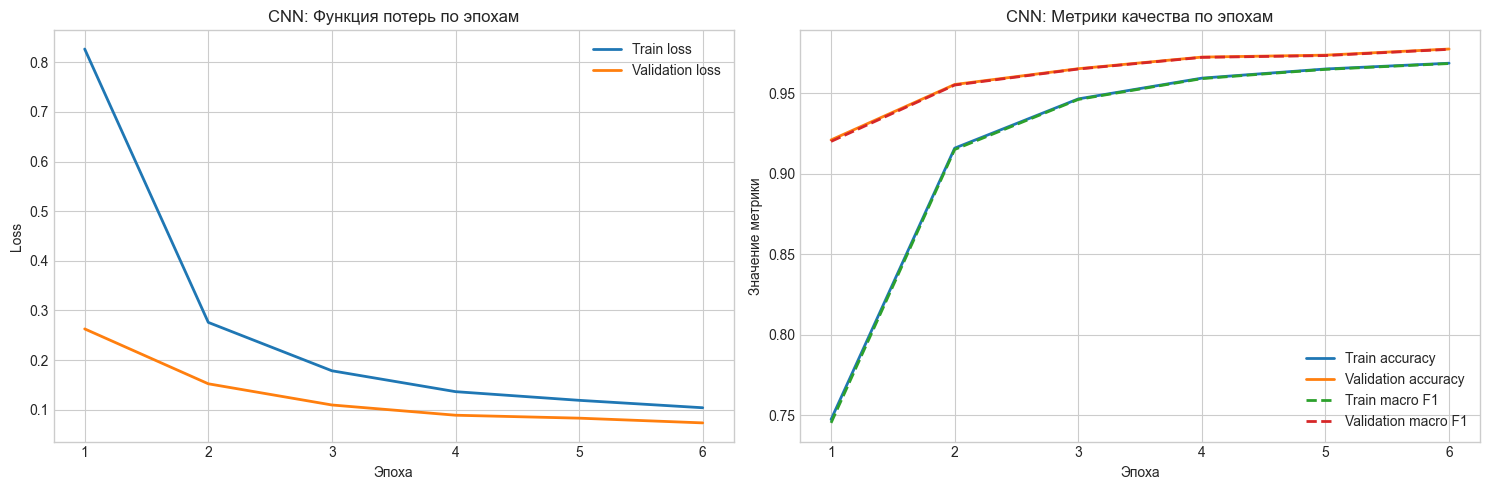

In [90]:
plot_history(cnn_history, title_prefix='CNN: ')


## 8. Визуализация активаций CNN


In [91]:
sample_index = 0
sample_image = x_test_tensor[sample_index:sample_index + 1].to(device)
sample_label = int(y_test_tensor[sample_index].item())

cnn_model.eval()
with torch.no_grad():
    sample_prediction = int(torch.argmax(cnn_model(sample_image), dim=1).item())
    activation1, activation2 = cnn_model.get_activations(sample_image)

activation1 = activation1.squeeze(0).cpu().numpy()
activation2 = activation2.squeeze(0).cpu().numpy()

print('Истинный класс:', sample_label)
print('Предсказанный класс:', sample_prediction)


Истинный класс: 7
Предсказанный класс: 7


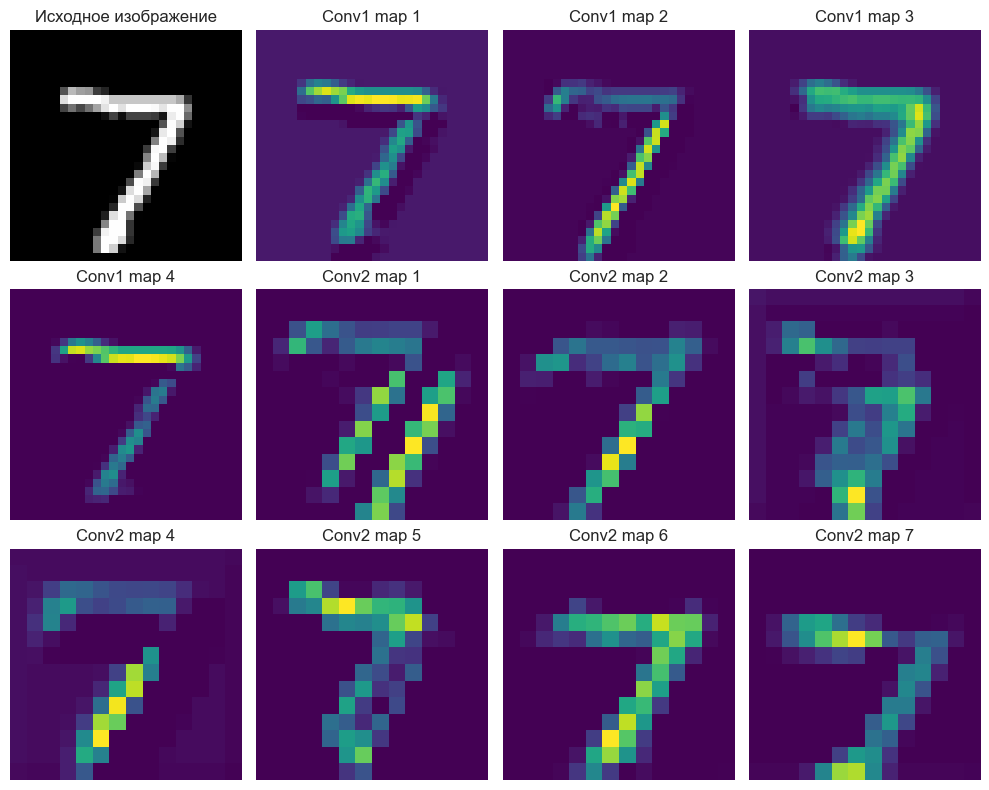

In [92]:
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.ravel()

axes[0].imshow(sample_image.squeeze().cpu().numpy(), cmap='gray')
axes[0].set_title('Исходное изображение')
axes[0].axis('off')

for i in range(1, 5):
    axes[i].imshow(activation1[i - 1], cmap='viridis')
    axes[i].set_title(f'Conv1 map {i}')
    axes[i].axis('off')

for i in range(5, 12):
    axes[i].imshow(activation2[i - 5], cmap='viridis')
    axes[i].set_title(f'Conv2 map {i - 4}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### Наблюдения

- первые карты активаций реагируют на края, линии и штрихи;
- второй свёрточный слой выделяет уже более сложные комбинации фрагментов цифры;
- часть карт почти пустая, а часть фокусируется на наиболее информативных областях изображения.


## 9. Итоговое сравнение


In [93]:
all_results = {
    'MLP ReLU + regularization': (baseline_test_loss, baseline_test_acc, baseline_test_f1),
    'MLP ReLU without regularization': (no_reg_test_loss, no_reg_test_acc, no_reg_test_f1),
    'MLP Sigmoid + regularization': (sigmoid_test_loss, sigmoid_test_acc, sigmoid_test_f1),
    'CNN': (cnn_test_loss, cnn_test_acc, cnn_test_f1),
}

for model_name, (loss_value, accuracy_value, f1_value) in all_results.items():
    print(model_name)
    print(f'  loss     = {loss_value:.4f}')
    print(f'  accuracy = {accuracy_value:.4f}')
    print(f'  macro F1 = {f1_value:.4f}')
    print()


MLP ReLU + regularization
  loss     = 0.0787
  accuracy = 0.9766
  macro F1 = 0.9764

MLP ReLU without regularization
  loss     = 0.0883
  accuracy = 0.9740
  macro F1 = 0.9738

MLP Sigmoid + regularization
  loss     = 0.1605
  accuracy = 0.9527
  macro F1 = 0.9523

CNN
  loss     = 0.0625
  accuracy = 0.9799
  macro F1 = 0.9798



## Итоговые выводы

1. Базовая `MLP` с `ReLU` и регуляризацией показывает высокое качество и устойчивые кривые обучения.
2. Удаление регуляризации на `MNIST` ухудшает результат слабо, потому что датасет простой и сеть не слишком большая.
3. Замена `ReLU` на сигмоиду приводит к более медленному обучению и более слабым метрикам.
4. Простая `CNN` показывает лучший результат, так как лучше использует пространственную структуру изображения.
